# PART9_Validate_breeding_plan

validate breeding strategy using F2 genotypes from N17-071 x N08-011, N01-162 x N08-011

In [3]:
import random
import copy
import ast
import math
import numpy as np
import pandas as pd
import pickle
from tqdm import tqdm
from glob import glob

from sklearn.linear_model import ElasticNet
from modules.training_module import train_Enet
from modules.make_data_for_prediction import make_data
from modules.breeding import make_regional_info, get_top_regions, plot_regional_info, plot_regional_info_with_target, target_effect_summary, visualize_line_genotype, visualize_RIL_genotype, visualize_F3_genotype
from modules.simulation import get_input_for_recombination, get_recombination_points, convert_genotype_to_pair, cross, check_target_regions, check_approximate_Hitomebore_ratio

## Predict phenotypic values of F2 genotypes

In [24]:
F2_genotype = pd.read_csv("../data/PART9_Validate_breeding_plan/Haplotype_F2_LD90.csv")
for i, each_chr in enumerate(F2_genotype.chr.unique()):
    chr_genotype = F2_genotype[F2_genotype["chr"] == each_chr]
    pos_array = chr_genotype.pos.str.split("_", expand=True).values.flatten()
    pos_array = pos_array[pos_array != None].astype("int")
    end = pos_array.max()
pos_array = F2_genotype.pos.str.split("_", expand=True).values
pos = np.array([[int(each_pos[0]), int(each_pos[0])] if each_pos[1] == None else [int(each_pos[0]), int(each_pos[1])] for each_pos in pos_array])
F2_genotype["start"] = pos[:, 0]
F2_genotype["end"] = pos[:, 1]
imp_data = pd.read_csv("../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits_add.csv", dtype={'N01':str,'N03':str,'N04':str,'N05':str,'N06':str,'N07':str,'N08':str,'N09':str,'N10':str,'N11':str,'N12':str,'N13':str,'N14':str,'N16':str,'N17':str,'N18':str,'N19':str,'N20':str,'N21':str,'N22':str})
marker_for_pred = imp_data.loc[:, ["chr", "start", "end"]]
marker_for_pred["key"] = marker_for_pred["chr"] + "_" + marker_for_pred["start"].astype("str") + "_" + marker_for_pred["end"].astype("str")
F2_genotype["key"] = F2_genotype["chr"] + "_" + F2_genotype["start"].astype("str") + "_" + F2_genotype["end"].astype("str")
F2_genotype_for_preds = F2_genotype.loc[F2_genotype["key"].isin(marker_for_pred["key"])].iloc[:, 3:-3].T.fillna(0)

In [31]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
k = 1
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV = 5
predicted_data = []
for trait_name in ["GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    print(trait_name)
    genotype_path = "../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv" 
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype_path, phenotype, CV, seed=1024, plot=False, log=False)
    ideal_preds = []
    for i in range(CV):
        Enet_params = pd.read_csv("../data/PART6_Select_genomic_regions_and_useful_RILs/Enet_high_imp_HBs_params.csv", index_col=0)
        Enet_params.columns = ["trait", "CV", "params"]
        Enet_params = ast.literal_eval(Enet_params.loc[(Enet_params["trait"] == trait_name) & (Enet_params["CV"] == i), "params"].values[0])
        tmp_train_data = train_data[i] 
        X_train = tmp_train_data[0].fillna(1)
        y_train = tmp_train_data[1]
        # train model
        clf = ElasticNet(alpha=Enet_params["alpha"], l1_ratio=Enet_params["l1_ratio"], max_iter=100000)
        clf.fit(X_train, y_train)
        # predicted values of test phenotype
        ideal_pred = clf.predict(F2_genotype_for_preds)
        ideal_preds.append(ideal_pred)
    ideal_preds = np.mean(ideal_preds, axis=0)
    predicted_data.append(ideal_preds)
predicted_data = pd.DataFrame(predicted_data)
predicted_data.index = ["GN_mean", "PN_mean", "Area.size.AS..mm2."]
predicted_data.columns = F2_genotype_for_preds.index.values
predicted_data

,GP_A_08_S29,GP_A_29_S37,GP_A_28_S36,GP_A_32_S38,GP_A_13_S32,GP_A_34_S40,GP_A_35_S41,GP_A_09_S30,GP_A_06_S28,GP_A_10_S31,GP_B_11_S60,GP_B_09_S58,GP_B_10_S59,GP_B_02_S51,GP_B_25_S74,GP_B_19_S68,GP_B_01_S50,GP_B_12_S61,GP_B_04_S53,GP_B_06_S55
GN_mean,176.197423,153.400254,142.132736,154.058970,147.789713,152.366452,140.624190,140.896714,129.795819,92.475156,182.123573,167.902310,180.464899,165.524839,188.074481,128.537701,149.310124,135.028572,171.083313,139.787029
PN_mean,17.265815,16.767146,17.367593,16.464005,17.842492,17.450945,17.009548,15.826123,17.555278,18.856649,16.091394,15.770739,15.125006,17.354197,14.237398,18.280136,16.416370,17.942688,15.213561,17.384068
Area.size.AS..mm2.,16.101133,17.389523,17.040428,17.928128,16.347266,17.653007,16.957961,18.187965,17.208323,16.116084,15.730324,14.987136,15.296633,13.804198,15.487487,16.124696,16.560436,15.314192,15.101610,14.820584


,F3,sample_num,GN,GN_std,PN,PN_std,GS,GS_std,pred_GN,pred_PN,pred_GS
0,GP_A_08_S29,32,174.375000,28.360297,18.031250,3.971547,14.916417,0.436083,176.197422,17.265815,16.101133
1,GP_A_29_S37,16,131.875000,14.957161,16.062500,2.379601,15.469654,0.381000,153.400254,16.767146,17.389523
2,GP_A_28_S36,16,129.250000,26.672083,17.625000,2.552776,15.371107,0.489183,142.132736,17.367593,17.040428
3,GP_A_32_S38,16,137.687500,25.637781,15.625000,3.030402,14.982524,0.368733,154.058970,16.464005,17.928128
4,GP_A_13_S32,16,127.062500,27.583736,19.625000,4.014557,14.341656,0.495237,147.789713,17.842492,16.347266
5,GP_A_34_S40,9,135.111111,19.839635,18.555556,2.650996,16.498241,0.446114,152.366452,17.450945,17.653008
6,GP_A_35_S41,12,138.000000,28.812876,19.333333,4.119429,15.410711,0.492745,140.624190,17.009548,16.957961
7,GP_A_09_S30,7,142.142857,9.044862,16.714286,3.352327,16.390142,0.488293,140.896714,15.826123,18.187965
8,GP_A_06_S28,10,122.900000,19.547378,20.500000,4.576510,14.974762,0.533649,129.795819,17.555278,17.208323
9,N17_071_S87,8,233.875000,15.578717,15.500000,1.772811,15.834537,0.329287,192.333138,13.192552,17.602511


0.8553551636059221
0.6889843907373945
0.6607025390327637


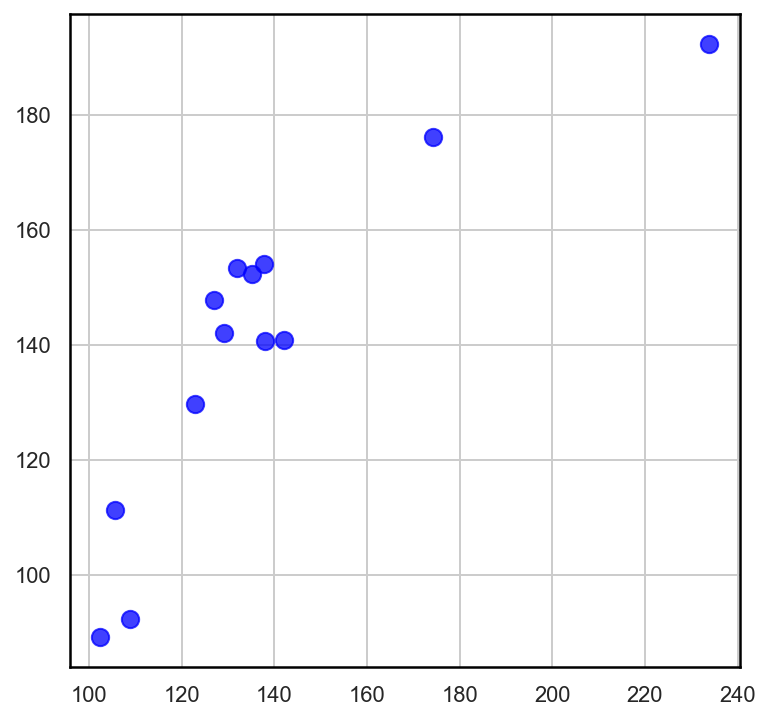

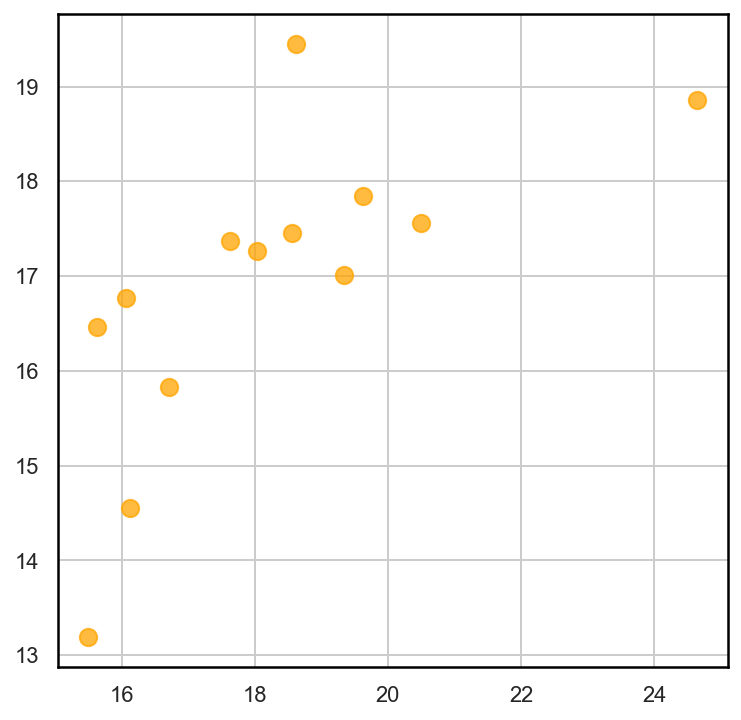

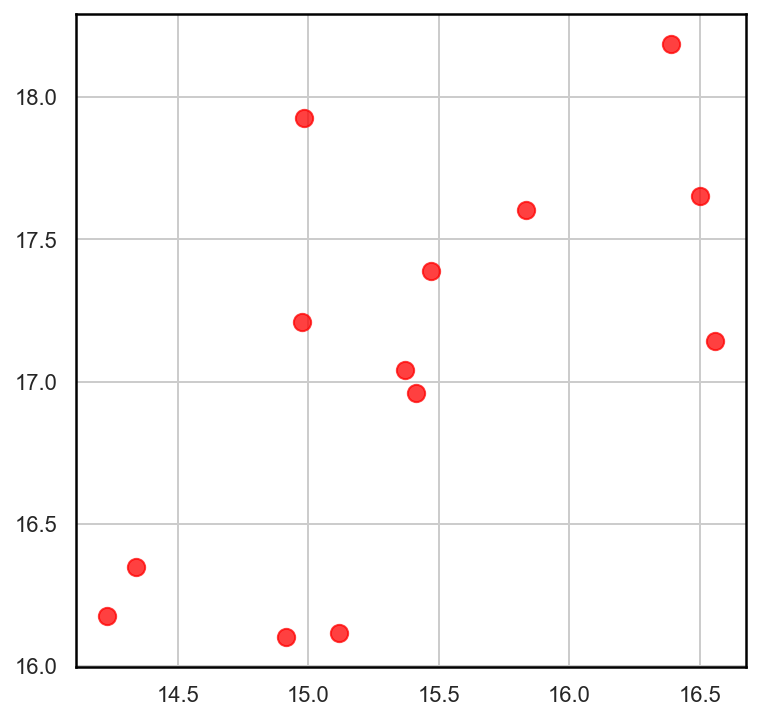

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}
sns.set()

mean_phenotypes = pd.read_csv("../data/PART9_Validate_breeding_plan/N17N08_F2_mean_phenotypes.csv")
display(mean_phenotypes)
print(np.corrcoef([mean_phenotypes["pred_GN"].values.astype("float"), mean_phenotypes["GN"].values.astype("float")])[0,1])
print(np.corrcoef([mean_phenotypes["pred_PN"].values.astype("float"), mean_phenotypes["PN"].values.astype("float")])[0,1])
print(np.corrcoef([mean_phenotypes["pred_GS"].values.astype("float"), mean_phenotypes["GS"].values.astype("float")])[0,1])

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(data=mean_phenotypes, x="GN", y="pred_GN", s=75, color="blue", linewidth=1, alpha=0.75)
for sp in ["top", "left", "right", "bottom"]:
    ax.spines[sp].set_color('black')
plt.show()

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(data=mean_phenotypes, x="PN", y="pred_PN", s=75, color="orange", linewidth=1, alpha=0.75)
for sp in ["top", "left", "right", "bottom"]:
    ax.spines[sp].set_color('black')
plt.show()

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(data=mean_phenotypes, x="GS", y="pred_GS", s=75, color="red", linewidth=1, alpha=0.75)
for sp in ["top", "left", "right", "bottom"]:
    ax.spines[sp].set_color('black')
plt.show()

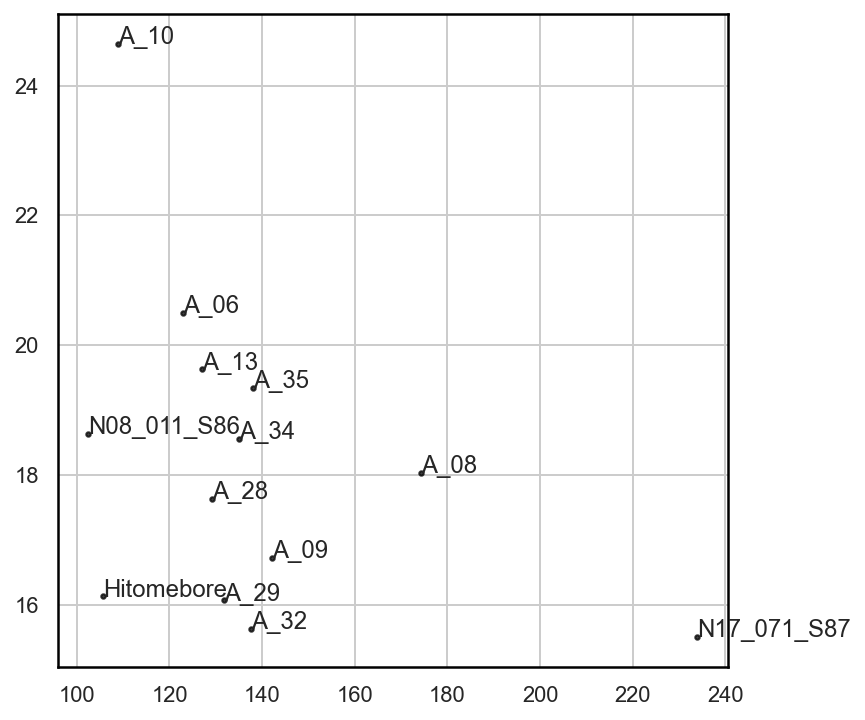

In [38]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6,6))
sc = ax.scatter(data=mean_phenotypes, x="GN", y="PN", s=5, c="black", linewidth=1, alpha=0.75)

for i, txt in enumerate(mean_phenotypes.F3.values):
    if txt[:2] == "GP":
        txt = txt[3:7]
    ax.annotate(txt, (mean_phenotypes.GN.values[i], mean_phenotypes.PN.values[i]))
    
for sp in ["top", "left", "right", "bottom"]:
    ax.spines[sp].set_color('black')
    
plt.show()

,F3,sample_num,GN,GN_std,PN,PN_std,GS,GS_std,pred_GN,pred_PN,pred_GS
0,GP_B_11_S60,29,167.310345,18.516602,19.586207,3.417573,13.880737,0.531095,182.123573,16.091394,15.730324
1,GP_B_09_S58,30,173.700000,18.728827,17.433333,3.793673,13.718724,0.584747,167.902310,15.770739,14.987136
2,GP_B_10_S59,21,191.952381,30.495043,17.047619,2.940683,15.769764,0.515317,180.464899,15.125006,15.296633
3,GP_B_02_S51,32,172.531250,21.002280,18.843750,3.646557,14.025906,0.303602,165.524839,17.354197,13.804198
4,GP_B_25_S74,16,183.250000,22.489998,14.437500,2.502499,14.965491,0.437753,188.074481,14.237398,15.487487
5,N01_162_S85,8,229.375000,24.023426,14.250000,1.982062,14.723013,0.421269,211.947872,13.418410,14.916842
6,GP_B_19_S68,16,129.812500,14.053321,19.937500,4.138740,15.424481,0.701899,128.537701,18.280136,16.124696
7,GP_B_01_S50,33,146.515152,17.986316,16.727273,3.599242,17.739212,0.514255,149.310124,16.416370,16.560436
8,GP_B_12_S61,16,116.250000,12.052662,22.437500,1.824600,15.069772,0.461292,135.028572,17.942688,15.314192
9,N08_011_S86,8,102.500000,11.045361,18.625000,3.777282,14.228119,0.130200,90.346104,19.206798,16.199126


0.9596359843272911
0.8099101238304383
0.639268607449786


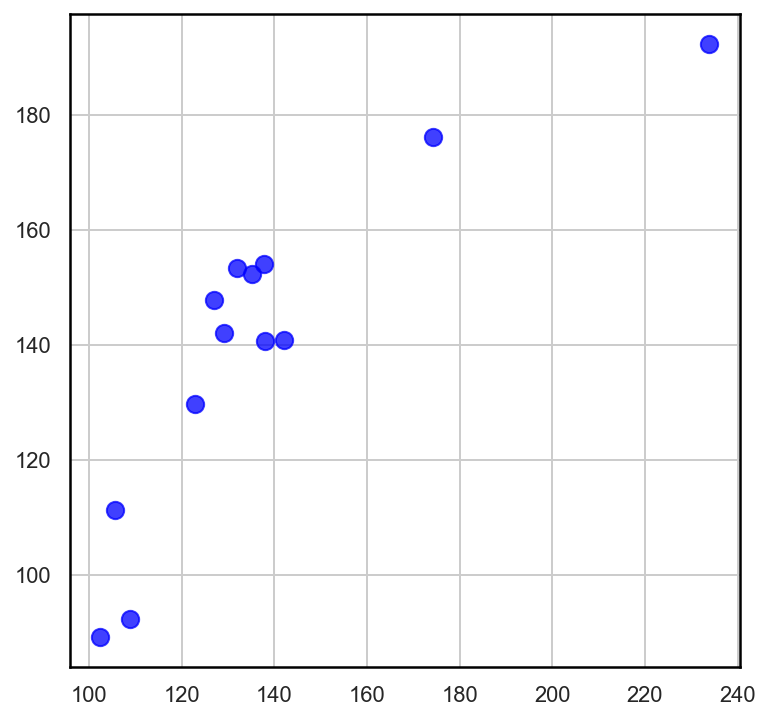

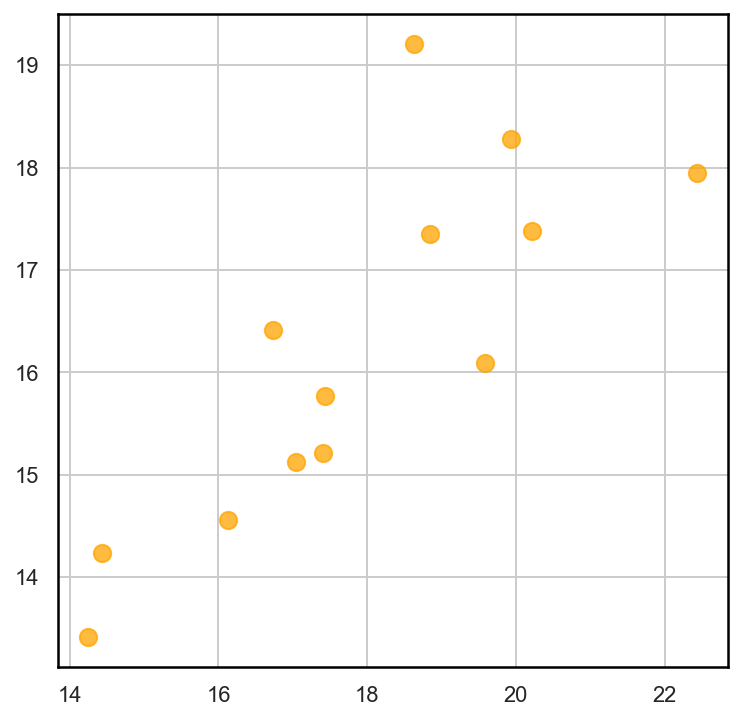

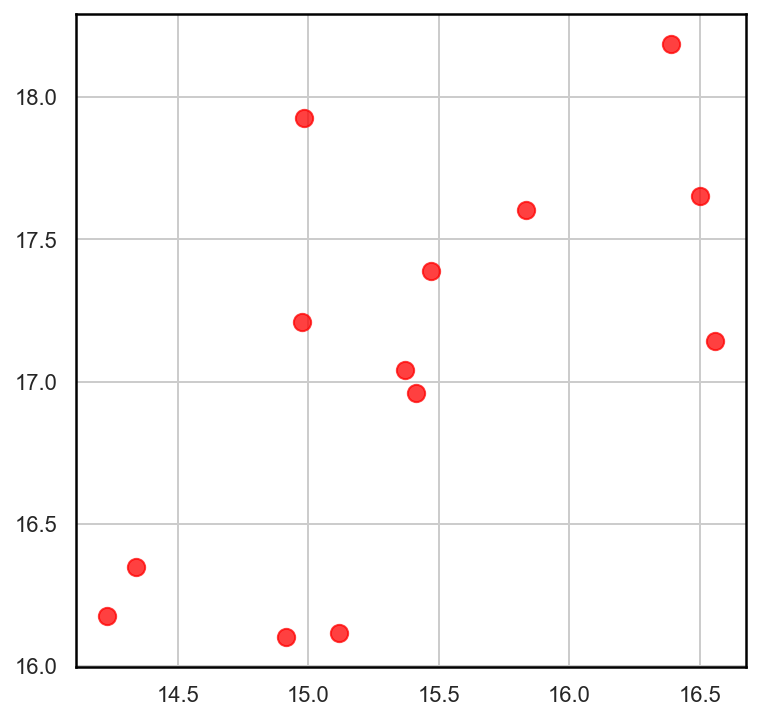

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}
sns.set()

mean_phenotypes = pd.read_csv("../data/PART9_Validate_breeding_plan/N01N08_F2_mean_phenotypes.csv")
display(mean_phenotypes)
print(np.corrcoef([mean_phenotypes["pred_GN"].values.astype("float"), mean_phenotypes["GN"].values.astype("float")])[0,1])
print(np.corrcoef([mean_phenotypes["pred_PN"].values.astype("float"), mean_phenotypes["PN"].values.astype("float")])[0,1])
print(np.corrcoef([mean_phenotypes["pred_GS"].values.astype("float"), mean_phenotypes["GS"].values.astype("float")])[0,1])

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(data=tmp_mean_phenotypes, x="GN", y="pred_GN", s=75, color="blue", linewidth=1, alpha=0.75)
for sp in ["top", "left", "right", "bottom"]:
    ax.spines[sp].set_color('black')
plt.show()

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(data=mean_phenotypes, x="PN", y="pred_PN", s=75, color="orange", linewidth=1, alpha=0.75)
for sp in ["top", "left", "right", "bottom"]:
    ax.spines[sp].set_color('black')
plt.show()

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(data=tmp_mean_phenotypes, x="GS", y="pred_GS", s=75, color="red", linewidth=1, alpha=0.75)
for sp in ["top", "left", "right", "bottom"]:
    ax.spines[sp].set_color('black')
plt.show()

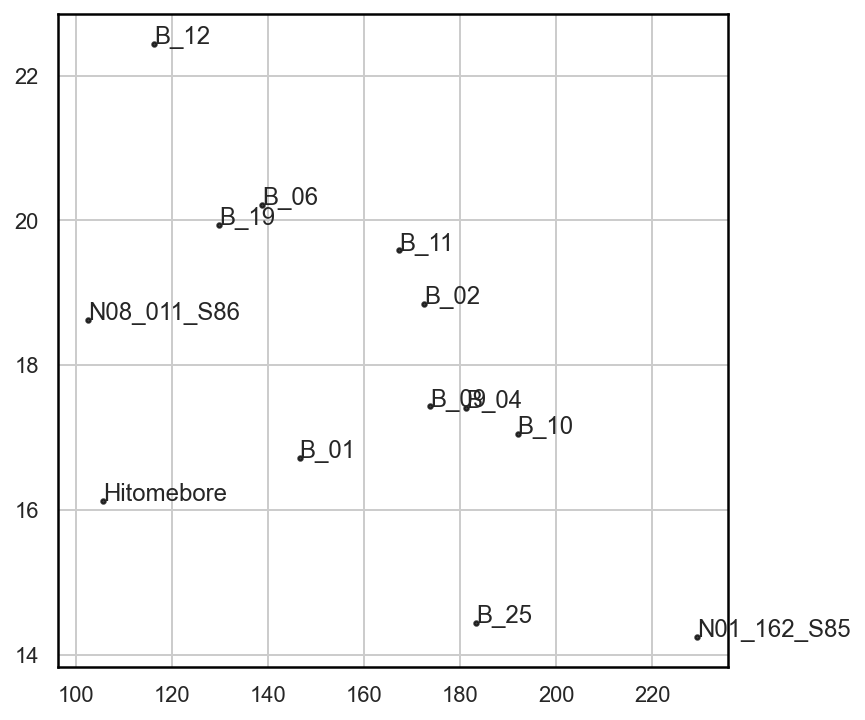

In [42]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6,6))
sc = ax.scatter(data=mean_phenotypes, x="GN", y="PN", s=5, c="black", linewidth=1, alpha=0.75)

for i, txt in enumerate(mean_phenotypes.F3.values):
    if txt[:2] == "GP":
        txt = txt[3:7]
    ax.annotate(txt, (mean_phenotypes.GN.values[i], mean_phenotypes.PN.values[i]))
    
for sp in ["top", "left", "right", "bottom"]:
    ax.spines[sp].set_color('black')
    
plt.show()